In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Buffon's Needle Simulator
def buffon_sim(num_trials, needle_len, spacing):
  """Simulate dropping needles and return number that hit a line."""
  center_x = np.random.uniform(0, spacing/2, num_trials)
  theta = np.random.uniform(0, np.pi/2, num_trials)
  hits = center_x <= (needle_len / 2) * np.sin(theta)
  return hits.sum()

def estimate_pi(num_trials, needle_len, spacing):
  hits = buffon_sim(num_trials, needle_len, spacing)
  return (2 * needle_len * num_trials) / (spacing * hits)

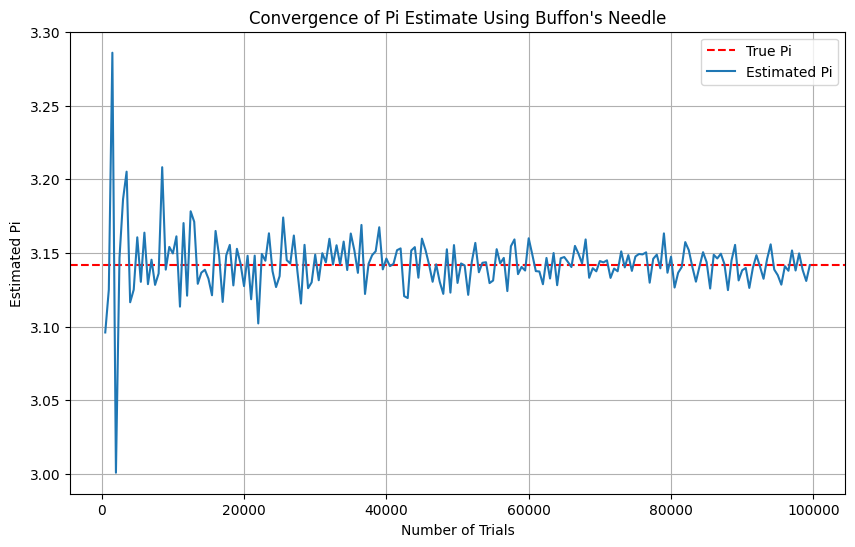

In [12]:
# 1. Convergence Plot
num_trials = 100_000
needle_length = 1.0
line_spacing = 1.0
trial_range = np.arange(500, num_trials, 500)
estimates = [estimate_pi(t, needle_length, line_spacing) for t in trial_range]

plt.figure(figsize=(10,6))
plt.axhline(np.pi, color='r', linestyle='--', label='True Pi')
plt.plot(trial_range, estimates, label="Estimated Pi")
plt.xlabel("Number of Trials")
plt.ylabel("Estimated Pi")
plt.title("Convergence of Pi Estimate Using Buffon's Needle")
plt.legend()
plt.grid(True)
plt.savefig('pi_convergence.png', dpi=150)

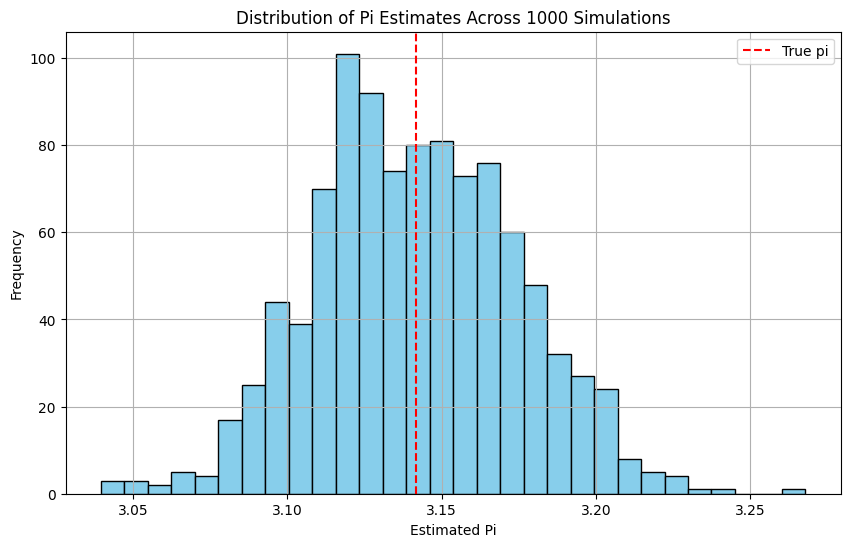

In [13]:
# 2. Histogram of Estimates Across Multiple Simulations
num_simulations = 1000
simulation_estimates = [estimate_pi(5000, needle_length, line_spacing) for _ in range(num_simulations)]

plt.figure(figsize=(10,6))
plt.hist(simulation_estimates, bins=30, color='skyblue', edgecolor='black')
plt.axvline(np.pi, color='r', linestyle='--', label='True pi')
plt.xlabel('Estimated Pi')
plt.ylabel('Frequency')
plt.title(f'Distribution of Pi Estimates Across {num_simulations} Simulations')
plt.legend()
plt.grid(True)
plt.savefig('pi_histogram.png', dpi=150)

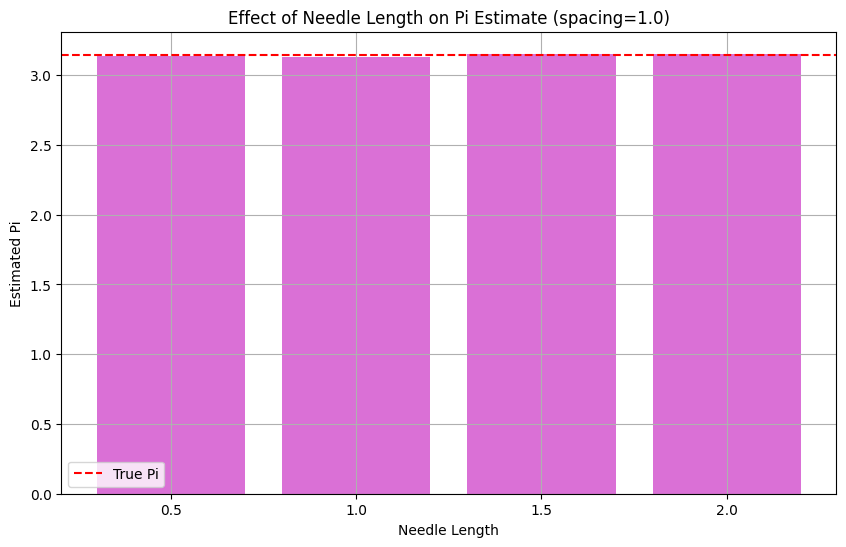

In [17]:
# 3. Simulate different needle lengths vs spacing
lengths = [0.5, 1.0, 1.5, 2.0]
num_trials = 50_000
pi_estimates_lengths = [estimate_pi(num_trials, 1, line_spacing) for l in lengths]

plt.figure(figsize=(10,6))
plt.bar([str(l) for l in lengths], pi_estimates_lengths, color='orchid')
plt.axhline(np.pi, color='r', linestyle='--', label='True Pi')
plt.xlabel('Needle Length')
plt.ylabel('Estimated Pi')
plt.title(f'Effect of Needle Length on Pi Estimate (spacing={line_spacing})')
plt.legend()
plt.grid(True)
plt.savefig('pi_vs_length.png', dpi=150)

In [20]:
# 4. Visualization of Some Needle Drops
num_needles_demo = 50
centers = np.random.uniform(0, line_spacing, num_needles_demo)
thetas = np.random.uniform(0, np.pi, num_needles_demo)
x0 = centers
y0 = np.zeros(num_needles_demo) # baseline

plt.figure(figsize=(10,6))
for i in range(num_needles_demo):
  x1 = x0[i] + needle_length * np.cos(thetas[i])/2
  y1 = y0[i] + needle_length * np.sin(thetas[i])/2
  y2 = y0[i] - needle_length * np.sin(thetas[i])/2
  x2 = x0[i] - needle_length * np.cos(thetas[i])/2
  plt.plot([x2, x1], [y2, y1], color='blue')

#draw vertical lines
for k in range(-1, 3):
  plt.axvline(k*line_spacing, color='k', alpha=0.3)
plt.xlim(-0.5, 2.5)
plt.ylim(-1.5, 1.5)
plt.title('Sample Needle Drops')
plt.savefig('needle_demo.png', dpi=150)

plt.close('all')
print("Simulation completed. Images saved: pi_convergence.png, pi_histogram.png, pi_vs_length.png, needle_demo.png")

Simulation completed. Images saved: pi_convergence.png, pi_histogram.png, pi_vs_length.png, needle_demo.png
